# Домашняя работа 4. Визуализация данных о пассажирах «Титаника»

## 1. Чтение датасета

In [1]:
"""Задача 1. Чтение датасета Titanic.

Файл train.csv лежит или рядом с ноутбуком (так бывает в Colab), или в общей
папке DataSet/ (так он лежит в репозитории), поэтому путь ищется, а не
вписывается жёстко.
"""

from pathlib import Path

import pandas as pd


def find_dataset(filename: str = "train.csv") -> Path:
    """Ищет файл датасета в текущей папке и вверх по дереву каталогов."""
    for folder in [Path.cwd(), *Path.cwd().parents]:
        for candidate in (folder / filename, folder / "DataSet" / filename):
            if candidate.exists():
                return candidate
    raise FileNotFoundError(f"не найден файл {filename}")


# PassengerId — идентификатор пассажира, а не признак: делаем его индексом
df = pd.read_csv(find_dataset(), index_col="PassengerId")

print(f"строк: {df.shape[0]}, столбцов: {df.shape[1]}")
df.head()

строк: 891, столбцов: 11


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Настройка стиля графиков

In [2]:
# Единый стиль всех графиков: светлая сетка и размеры подписей
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["font.size"] = 11

# В данных лежат числа и коды, а на графиках нужны слова — словари подписей
SURVIVED_LABELS = {0: "Погиб", 1: "Выжил"}
SEX_LABELS = {"male": "Мужчины", "female": "Женщины"}
CLASS_LABELS = {1: "1 класс", 2: "2 класс", 3: "3 класс"}

## 2. Распределение значений признаков `Survived`, `Pclass`, `Age`, `Sex`, `Parch`

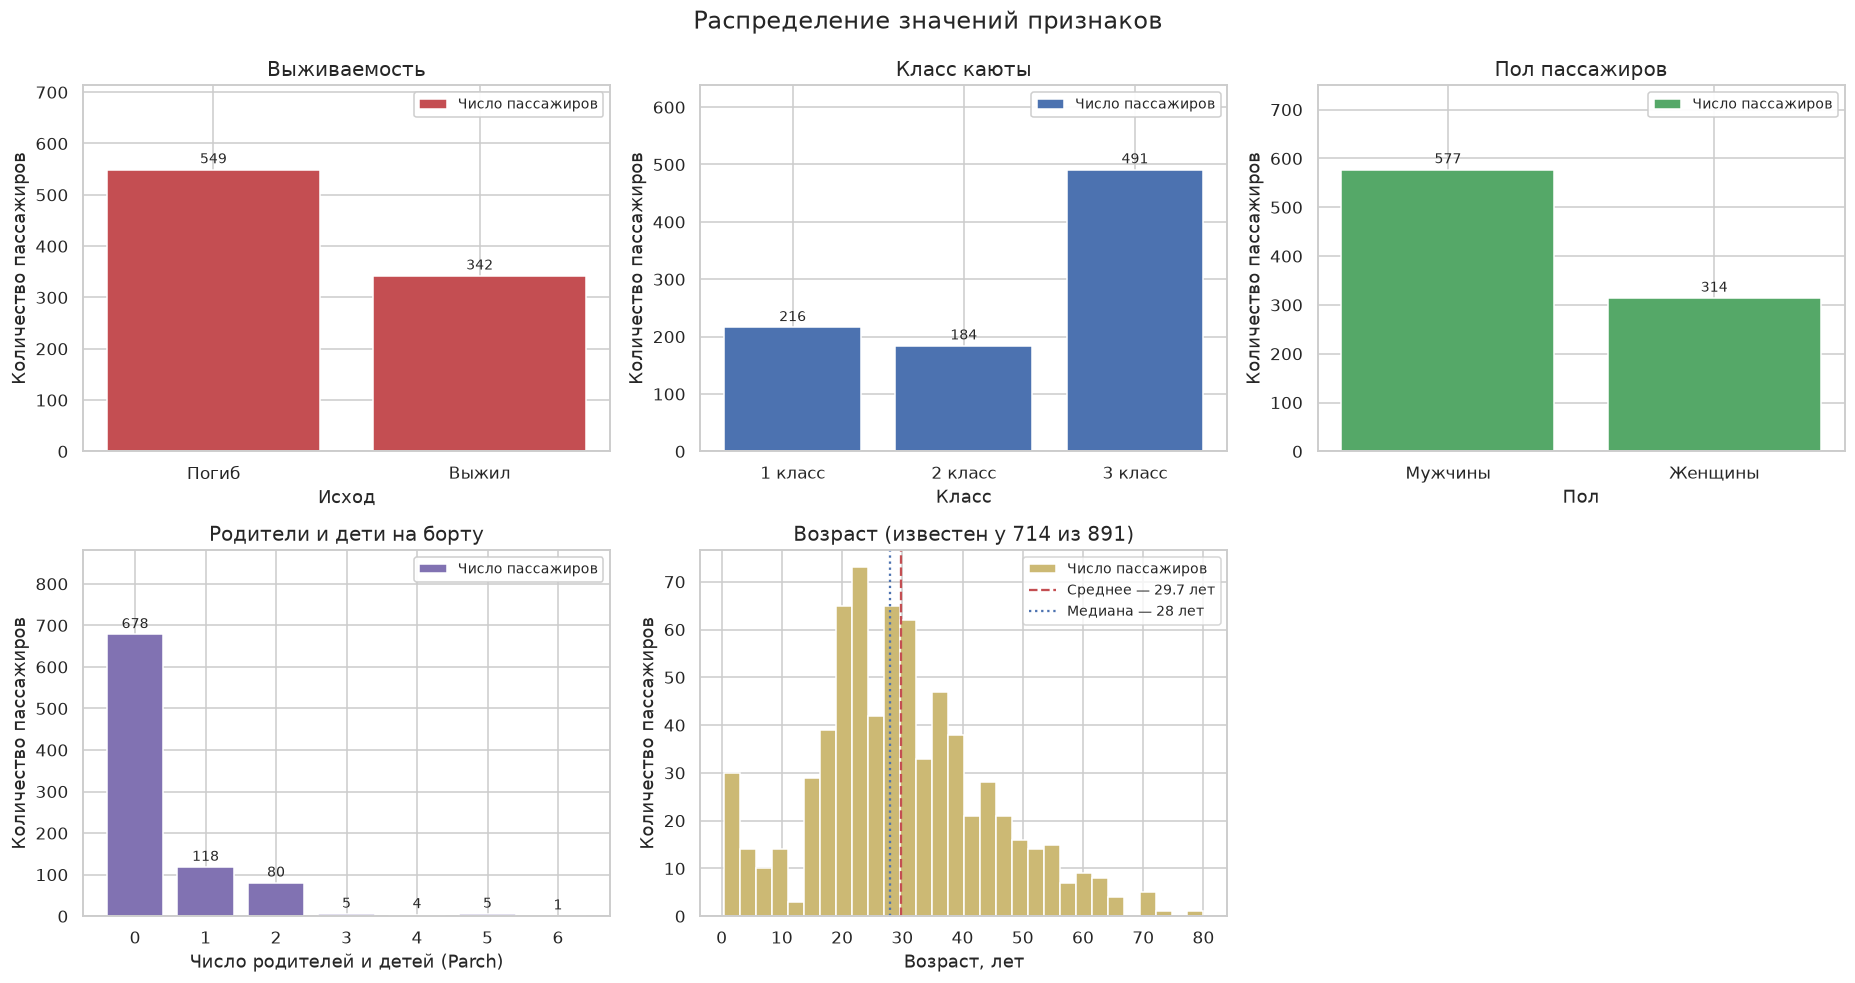

In [3]:
def bar_distribution(ax, counts, title, xlabel, labels=None, color="#4C72B0"):
    """Столбчатая диаграмма распределения категориального признака.

    counts — результат value_counts(): индекс это категория, значения — число
    пассажиров. labels переводит коды (0/1, male/female, 1/2/3) в слова.
    """
    names = [str(labels.get(i, i)) if labels else str(i) for i in counts.index]
    bars = ax.bar(names, counts.values, color=color, label="Число пассажиров")
    ax.bar_label(bars, padding=2, fontsize=9)        # подписи значений над столбцами
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Количество пассажиров")
    ax.set_ylim(0, counts.max() * 1.3)               # запас сверху, чтобы легенда не наезжала
    ax.legend(loc="upper right", fontsize=9, framealpha=0.95)


fig, axes = plt.subplots(2, 3, figsize=(17, 9))
fig.suptitle("Распределение значений признаков", fontsize=16, y=0.99)

bar_distribution(axes[0, 0], df["Survived"].value_counts().sort_index(),
                 "Выживаемость", "Исход", SURVIVED_LABELS, "#C44E52")
bar_distribution(axes[0, 1], df["Pclass"].value_counts().sort_index(),
                 "Класс каюты", "Класс", CLASS_LABELS)
bar_distribution(axes[0, 2], df["Sex"].value_counts(),
                 "Пол пассажиров", "Пол", SEX_LABELS, "#55A868")
bar_distribution(axes[1, 0], df["Parch"].value_counts().sort_index(),
                 "Родители и дети на борту", "Число родителей и детей (Parch)", None, "#8172B2")

# Age — непрерывный признак: для него не столбцы по категориям, а гистограмма,
# плюс вертикальные линии со средним и медианой для сравнения
ax = axes[1, 1]
ax.hist(df["Age"].dropna(), bins=30, color="#CCB974", edgecolor="white",
        label="Число пассажиров")
ax.axvline(df["Age"].mean(), color="#C44E52", linestyle="--",
           label=f"Среднее — {df['Age'].mean():.1f} лет")
ax.axvline(df["Age"].median(), color="#4C72B0", linestyle=":",
           label=f"Медиана — {df['Age'].median():.0f} лет")
ax.set_title(f"Возраст (известен у {df['Age'].notna().sum()} из {len(df)})")
ax.set_xlabel("Возраст, лет")
ax.set_ylabel("Количество пассажиров")
ax.legend(fontsize=9)

axes[1, 2].axis("off")   # шестая клетка сетки не нужна

fig.tight_layout()
plt.show()

## 3. Boxplot для столбца `Age`

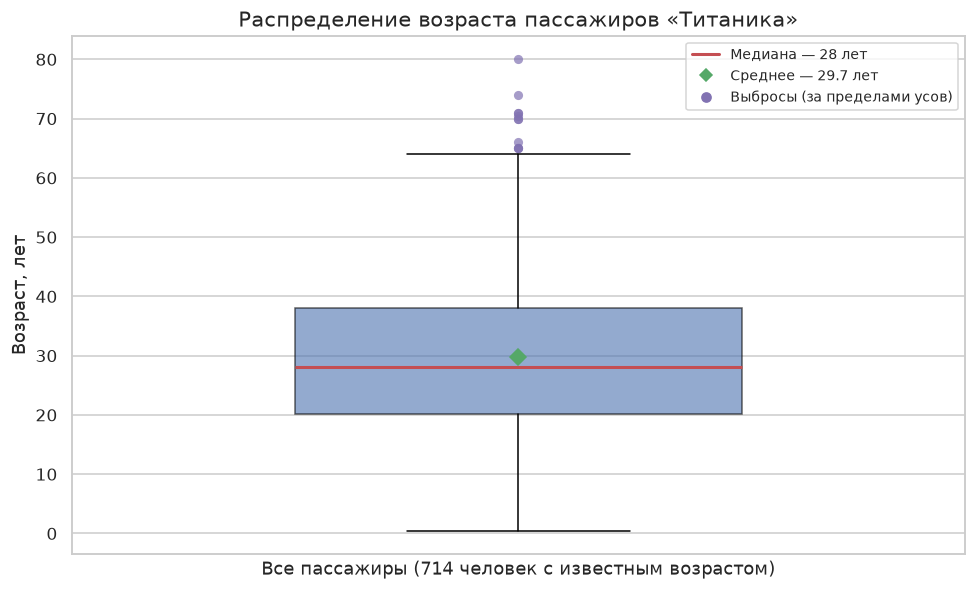

Q1 = 20.12 | медиана = 28.00 | Q3 = 38.00 | IQR = 17.88
усы: от 0.42 до 64.81 лет
выбросов: 11 (от 65 до 80 лет)


In [4]:
# Boxplot строится только по известным возрастам: пропуски пропускаем
age = df["Age"].dropna()

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.boxplot(
    age, widths=0.5, showmeans=True, patch_artist=True,
    boxprops=dict(facecolor="#4C72B0", alpha=0.6),
    medianprops=dict(color="#C44E52", linewidth=2),
    meanprops=dict(marker="D", markerfacecolor="#55A868",
                   markeredgecolor="#55A868", markersize=7),
    flierprops=dict(marker="o", markerfacecolor="#8172B2",
                    markeredgecolor="none", markersize=6, alpha=0.7),
)

# Элементы boxplot не попадают в легенду сами — собираем её вручную
from matplotlib.lines import Line2D

ax.legend(handles=[
    Line2D([], [], color="#C44E52", linewidth=2, label=f"Медиана — {age.median():.0f} лет"),
    Line2D([], [], marker="D", color="#55A868", linestyle="",
           label=f"Среднее — {age.mean():.1f} лет"),
    Line2D([], [], marker="o", color="#8172B2", linestyle="",
           label="Выбросы (за пределами усов)"),
], loc="upper right", fontsize=9)

ax.set_title("Распределение возраста пассажиров «Титаника»", fontsize=14)
ax.set_ylabel("Возраст, лет")
ax.set_xlabel("Все пассажиры (714 человек с известным возрастом)")
ax.set_xticks([])

fig.tight_layout()
plt.show()

q1, med, q3 = age.quantile([0.25, 0.5, 0.75])
iqr = q3 - q1
low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
print(f"Q1 = {q1:.2f} | медиана = {med:.2f} | Q3 = {q3:.2f} | IQR = {iqr:.2f}")
print(f"усы: от {max(age.min(), low):.2f} до {min(age.max(), high):.2f} лет")
print(f"выбросов: {((age < low) | (age > high)).sum()} "
      f"(от {age[(age < low) | (age > high)].min():.0f} до {age[(age < low) | (age > high)].max():.0f} лет)")

## 4. Интерпретация графика

**Центр и разброс.** Медиана — 28 лет: половина пассажиров моложе этого возраста. Коробка
охватывает межквартильный размах от Q1 = 20.1 до Q3 = 38 лет, то есть центральная половина
пассажиров укладывается примерно в 20–38 лет (IQR = 17.9 года). Корабль был молодым: четверть
пассажиров — не старше 20 лет.

**Асимметрия.** Среднее (29.7) лежит правее медианы (28), правая часть коробки шире левой, а
коэффициент асимметрии равен 0.39 — распределение скошено вправо. Причина в том, что снизу
возраст ограничен нулём, а сверху растянут пожилыми пассажирами: несколько 80-летних тянут
среднее вверх. Поэтому для возраста медиана честнее среднего.

**Усы и выбросы.** Нижний ус упирается в 0.42 года (пятимесячный младенец) — это реальный
минимум, потому что расчётная граница снизу отрицательна и смысла не имеет. Верхний ус
обрывается на 64.8 года, за ним boxplot помечает **11 выбросов** — пассажиров от 65 до 80 лет.
Это не ошибки данных, а настоящие пожилые люди: статистически редкие для выборки, но
достоверные, удалять их нельзя.

**Чего график не показывает.** Возраст известен только у 714 пассажиров из 891 — 177 значений
пропущено (почти 20 %). Boxplot молча строится по имеющимся данным, поэтому все выводы выше
относятся к 80 % выборки, а не ко всем пассажирам.

## 5. Круговые диаграммы (pie chart) для `Survived` и `Pclass`

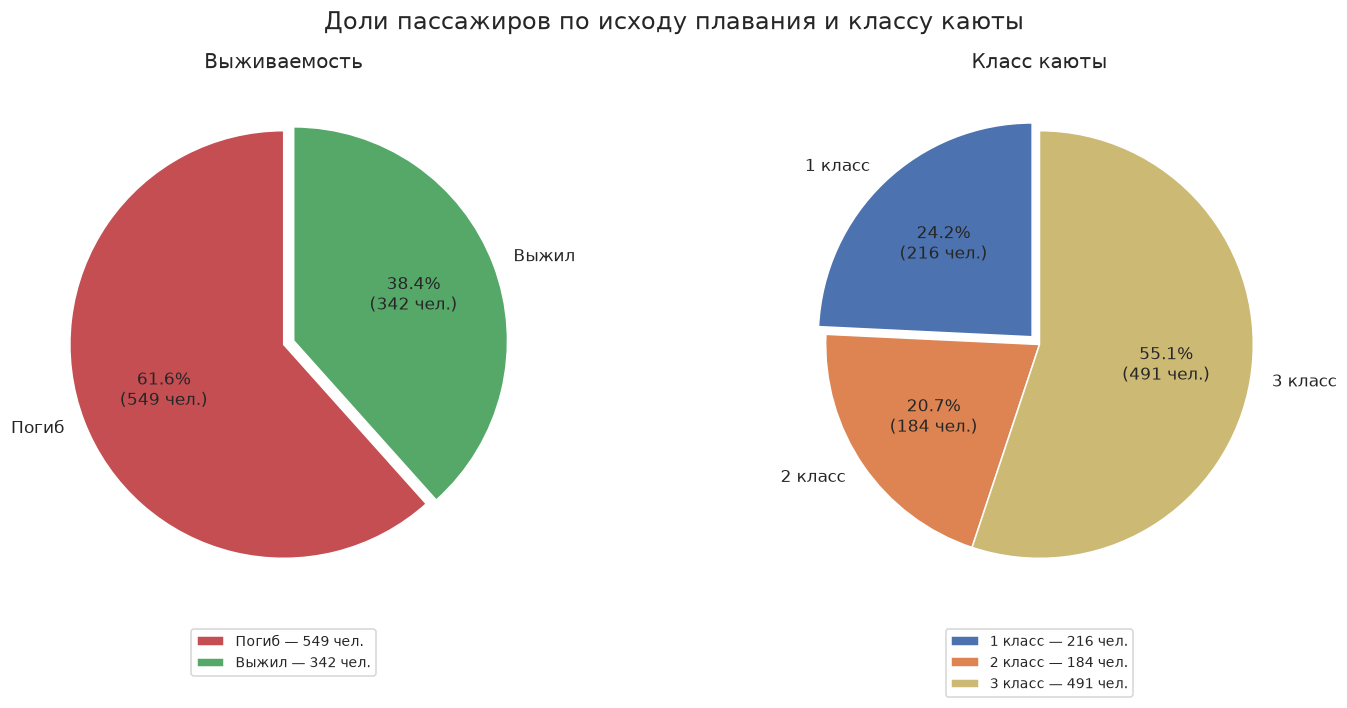

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))
fig.suptitle("Доли пассажиров по исходу плавания и классу каюты", fontsize=16)

# автоподпись долей: percent даёт процент, второй строкой показываем число людей
survived = df["Survived"].value_counts().sort_index()
axes[0].pie(
    survived.values,
    labels=[SURVIVED_LABELS[i] for i in survived.index],
    autopct=lambda p: f"{p:.1f}%\n({p * survived.sum() / 100:.0f} чел.)",
    colors=["#C44E52", "#55A868"], startangle=90, explode=(0, 0.05),
    textprops={"fontsize": 11},
)
axes[0].set_title("Выживаемость", fontsize=13)
axes[0].legend([f"{SURVIVED_LABELS[i]} — {survived[i]} чел." for i in survived.index],
               loc="upper center", bbox_to_anchor=(0.5, -0.02), fontsize=9)

pclass = df["Pclass"].value_counts().sort_index()
axes[1].pie(
    pclass.values,
    labels=[CLASS_LABELS[i] for i in pclass.index],
    autopct=lambda p: f"{p:.1f}%\n({p * pclass.sum() / 100:.0f} чел.)",
    colors=["#4C72B0", "#DD8452", "#CCB974"], startangle=90, explode=(0.05, 0, 0),
    textprops={"fontsize": 11},
)
axes[1].set_title("Класс каюты", fontsize=13)
axes[1].legend([f"{CLASS_LABELS[i]} — {pclass[i]} чел." for i in pclass.index],
               loc="upper center", bbox_to_anchor=(0.5, -0.02), fontsize=9)

fig.tight_layout()
plt.show()

## 6. Pairplot для всех числовых переменных

числовые признаки: ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


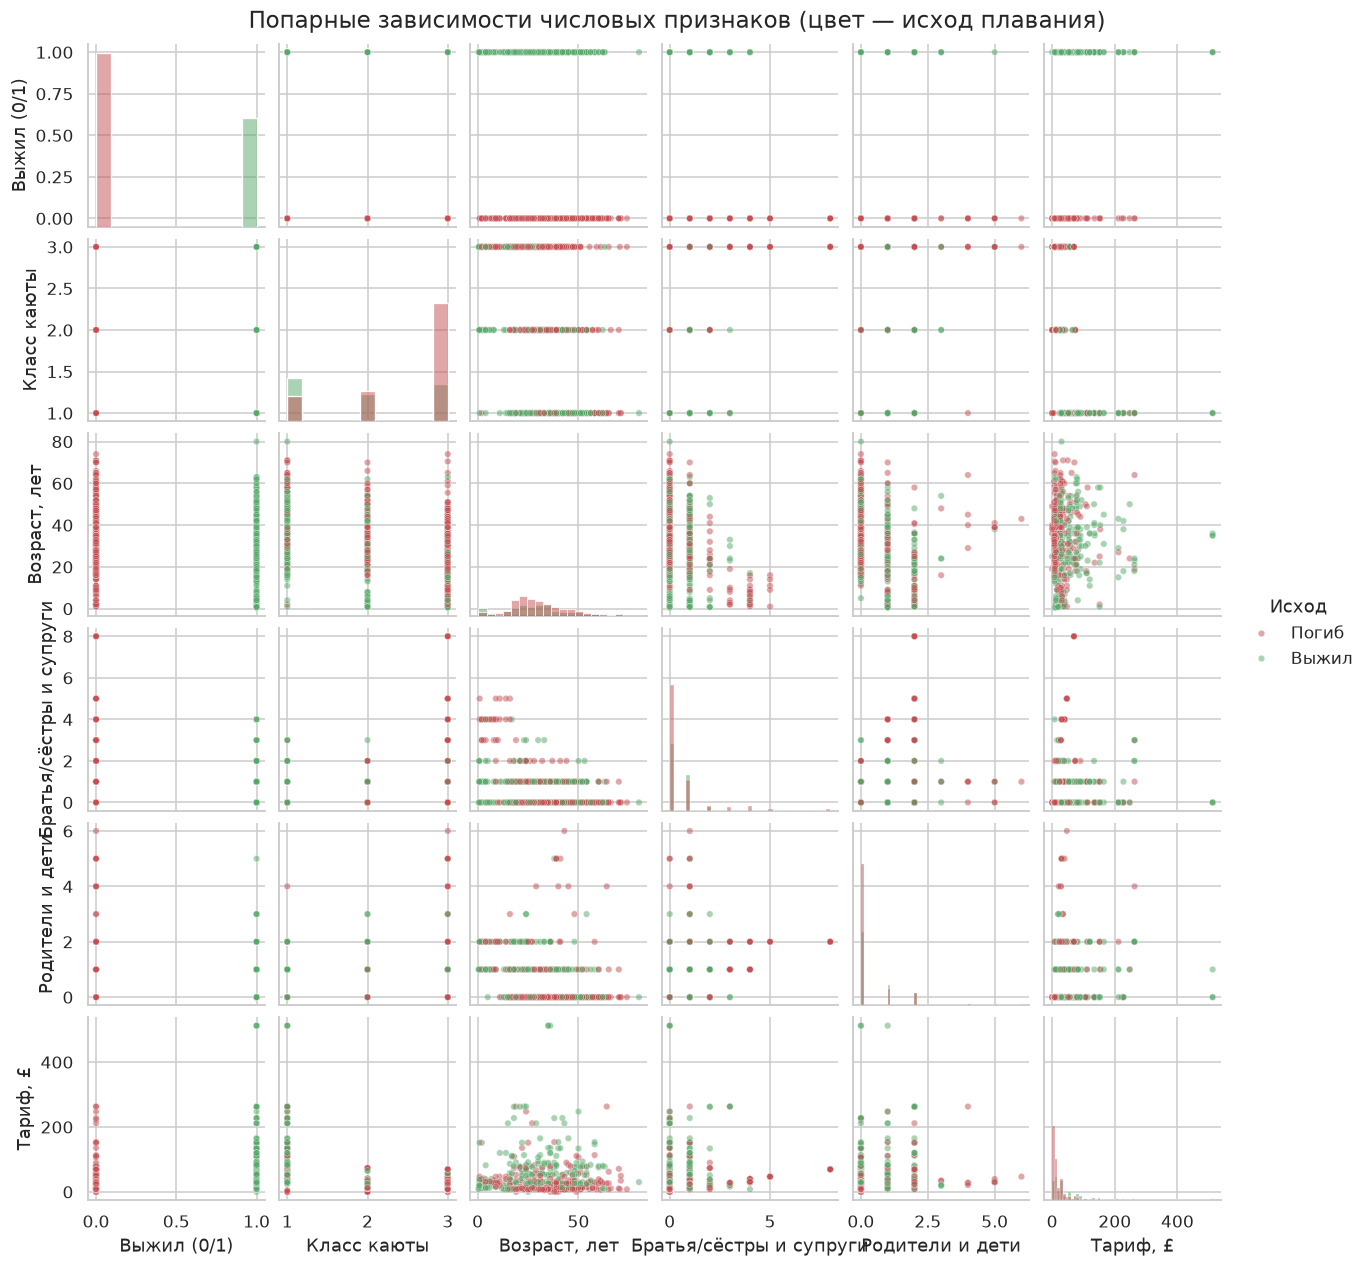

In [6]:
# Все числовые столбцы датасета: Survived, Pclass, Age, SibSp, Parch, Fare
numeric_columns = df.select_dtypes(include="number").columns.tolist()
print("числовые признаки:", numeric_columns)

# Копия с расшифрованным исходом, чтобы в легенде были слова, а не 0 и 1
paired = df[numeric_columns].copy()
paired["Исход"] = df["Survived"].map(SURVIVED_LABELS)

grid = sns.pairplot(
    paired, vars=numeric_columns, hue="Исход",
    palette={"Погиб": "#C44E52", "Выжил": "#55A868"},
    diag_kind="hist", plot_kws={"alpha": 0.5, "s": 18}, height=1.9,
)
grid.figure.suptitle("Попарные зависимости числовых признаков (цвет — исход плавания)",
                     fontsize=15, y=1.01)
grid.legend.set_title("Исход")

# Подписи осей: вместо имён столбцов — понятные названия с единицами измерения
AXIS_LABELS = {
    "Survived": "Выжил (0/1)", "Pclass": "Класс каюты", "Age": "Возраст, лет",
    "SibSp": "Братья/сёстры и супруги", "Parch": "Родители и дети", "Fare": "Тариф, £",
}
for i, column in enumerate(numeric_columns):
    grid.axes[-1, i].set_xlabel(AXIS_LABELS[column])
    grid.axes[i, 0].set_ylabel(AXIS_LABELS[column])

plt.show()

## 7. Интерактивный sunburst plot (plotly)

In [7]:
import plotly.express as px

# Два уровня иерархии: класс каюты -> пол внутри класса
hierarchy = df.groupby(["Pclass", "Sex"]).size().reset_index(name="Пассажиров")
hierarchy["Класс"] = hierarchy["Pclass"].map(CLASS_LABELS)
hierarchy["Пол"] = hierarchy["Sex"].map(SEX_LABELS)
display(hierarchy[["Класс", "Пол", "Пассажиров"]])

fig = px.sunburst(
    hierarchy,
    path=["Класс", "Пол"],          # первый уровень — класс, второй — пол внутри класса
    values="Пассажиров",
    color="Класс",
    color_discrete_map={"1 класс": "#4C72B0", "2 класс": "#DD8452", "3 класс": "#CCB974"},
    title="Пассажиры «Титаника»: классы и распределение по полу внутри класса",
)

# У sunburst нет отдельного блока легенды — её роль играют подписи секторов,
# поэтому выводим на них и название, и число людей, и долю в родительском кольце
fig.update_traces(
    textinfo="label+value+percent parent",
    hovertemplate="<b>%{label}</b><br>Пассажиров: %{value}<br>"
                  "Доля в родительском кольце: %{percentParent:.1%}<extra></extra>",
    insidetextorientation="radial",
)
fig.update_layout(width=750, height=750, title_x=0.5, title_font_size=16,
                  margin=dict(t=90, l=10, r=10, b=10))
fig.show()

,Класс,Пол,Пассажиров
0,1 класс,Женщины,94
1,1 класс,Мужчины,122
2,2 класс,Женщины,76
3,2 класс,Мужчины,108
4,3 класс,Женщины,144
5,3 класс,Мужчины,347


**Как читать график.** Внутреннее кольцо — классы кают, подпись показывает число пассажиров
и долю от всех 891. Внешнее кольцо — мужчины и женщины внутри своего класса, причём процент
считается от родительского сектора, а не от всего корабля: 71 % в третьем классе означает
«71 % пассажиров третьего класса — мужчины». График интерактивный: клик по сектору разворачивает
его на весь круг, клик в центр возвращает назад, при наведении всплывает подсказка с числами.